# Fusemachines AI Fellowship 2026
> ## Agentic Routing with LLMs & Transformers

**Topic:** Transformers, LLMs, and Foundation Models
**File to submit:** `<your_name>_support_routing.ipynb`: must run top-to-bottom without errors.

## 0. Assignment Overview

**Scenario.** You are on the AI engineering team at **ShopAssist AI**. Before any specialized
support agent can respond to a customer, an incoming message has to be **routed** to exactly
one of 11 agents. Your job is to prototype and benchmark **two** routing strategies and
recommend one for production.

| Agent | Intents it owns |
|---|---|
| ACCOUNT | create_account, delete_account, edit_account, switch_account |
| CANCEL | check_cancellation_fee |
| CONTACT | contact_customer_service, contact_human_agent |
| DELIVERY | delivery_options |
| FEEDBACK | complaint, review |
| INVOICE | check_invoice, get_invoice |
| SUBSCRIPTION | newsletter_subscription |
| ORDER | cancel_order, change_order, place_order |
| PAYMENT | check_payment_methods, payment_issue |
| REFUND | check_refund_policy, track_refund |
| SHIPPING | change_shipping_address, set_up_shipping_address |

**Dataset.** `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — use the `category`
column directly as your 11-class target (`instruction` is the customer message).


**What you will build:**
1. **Approach 1** — fine-tune an encoder-only transformer (BERT-family) as a `[CLS]`-token classifier.
2. **Approach 2** — fine-tune a decoder-only SLM (Qwen) to *generate* the agent name as a single token, optionally with LoRA.
3. A **comparison** of both approaches on the *same* held-out test set, a **recommendation**, and a **reflection**.

**Every `# TODO` marker in this notebook is something you need to implement.** Helper functions are provided so you can focus on the modeling decisions that matter for this topic (tokenization, model setup, training configuration, evaluation, and interpreting results).

## Setup

In [1]:
# 0. Setup and Installations
%pip install -q "transformers==4.49.0" "datasets==3.6.0" "evaluate==0.4.3" "peft==0.15.2" "accelerate==1.2.1" "trl==0.17.0" "scikit-learn==1.6.1" "matplotlib==3.10.3" "seaborn==0.13.2" "pandas==2.2.3"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Global Configuration

Read it carefully, since `TARGET_CATEGORIES`, `label2id`, `id2label`, and `NUM_LABELS` are used by **both** approaches below.

In [2]:
import torch
import gc
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, DatasetDict, ClassLabel, Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModelForCausalLM, Trainer, TrainingArguments,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Verify GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

RANDOM_SEED = 0
HF_DATA_ID = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"

# The 11 support agents == the 11 categories in the dataset (see Section 0 table).
TARGET_CATEGORIES = [
    'ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE',
    'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION'
]
NUM_LABELS = len(TARGET_CATEGORIES)
assert NUM_LABELS == 11, "Expected exactly 11 support agents / categories"

# If a model you pick requires authentication (gated repo), log in
# INTERACTIVELY -- never hardcode a token in a notebook you submit or share:
#
#   from huggingface_hub import login
#   login()   # prompts for a token, or reads the HF_TOKEN env var
#
# None of the candidate models below require this, so it's commented out.

C:\Users\siddh\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Helper Functions

These are given so both approaches can share identical:
- `get_metrics`: macro precision/recall/F1 + accuracy.
- `get_stratified_splits`: builds **one** train/validation/test split that Approach 1 and Approach 2 will **both** reuse (this is what guarantees "both approaches are evaluated on the same held-out test set").
- `plot_loss_curve`: plots train vs. validation loss from a `Trainer`'s `log_history`.
- `plot_confusion_matrix_heatmap`: confusion matrix heatmap for either integer or string labels.
- `measure_latency_and_memory`: times batch-size-1 inference and logs peak CUDA memory, after a short warm-up (so the first, slower CUDA-kernel-compilation call doesn't skew results).

In [3]:
def get_metrics(labels, preds):
    """
    Calculates macro-averaged evaluation metrics for classification.

    Args:
        labels: True ground truth labels.
        preds: Predicted labels from the model.

    Returns:
        A dictionary containing accuracy, precision, recall, and f1_score.
    """
    precision, recall, f1_score, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score
    }


def get_stratified_splits(dataset_id, target_categories, seed=RANDOM_SEED,
                           train_frac=0.8, val_frac=0.1, test_frac=0.1):
    """
    Loads the Bitext dataset, filters to `target_categories`, and returns a single
    stratified train/validation/test DatasetDict
    """
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    label2id = {c: i for i, c in enumerate(target_categories)}
    id2label = {i: c for c, i in label2id.items()}

    dataset = load_dataset(dataset_id, split="train")
    dataset = dataset.filter(lambda x: x["category"] in target_categories)
    dataset = dataset.map(lambda x: {"label": label2id[x["category"]]})
    dataset = dataset.cast_column("label", ClassLabel(names=target_categories))

    holdout_frac = val_frac + test_frac
    train_holdout = dataset.train_test_split(test_size=holdout_frac, stratify_by_column="label", seed=seed)
    val_test = train_holdout["test"].train_test_split(
        test_size=test_frac / holdout_frac, stratify_by_column="label", seed=seed
    )

    splits = DatasetDict({
        "train": train_holdout["train"],
        "validation": val_test["train"],
        "test": val_test["test"],
    })
    return splits, label2id, id2label


def plot_loss_curve(log_history, title="Training Loss"):
    """Given a HF Trainer's `trainer.state.log_history`, plot train vs. eval loss per step."""
    train_steps, train_losses = [], []
    eval_steps, eval_losses = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry.get("step", len(train_steps)))
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry.get("step", len(eval_steps)))
            eval_losses.append(entry["eval_loss"])

    plt.figure(figsize=(8, 5))
    if train_losses:
        plt.plot(train_steps, train_losses, label="Train Loss", marker="o")
    if eval_losses:
        plt.plot(eval_steps, eval_losses, label="Validation Loss", marker="s")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion_matrix_heatmap(labels, preds, class_names, title="Confusion Matrix"):
    """Confusion matrix heatmap. Works with integer labels or category-name strings."""
    use_names = isinstance(labels[0], str)
    cm = confusion_matrix(labels, preds, labels=class_names if use_names else list(range(len(class_names))))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def measure_latency_and_memory(predict_one_fn, examples, warmup=3):
    """
    Calls predict_one_fn(example) once per example (batch_size=1, matching a
    realistic single-request serving scenario). Resets CUDA peak-memory stats
    after warm-up so the very first (slow, kernel-compiling) call doesn't
    skew latency, and the reported peak memory reflects only steady-state
    inference.
    """
    examples = list(examples)
    for example in examples[:warmup]:
        _ = predict_one_fn(example)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    predictions = []
    start = time.time()
    for example in examples:
        predictions.append(predict_one_fn(example))
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.time()

    avg_latency_ms = (end - start) / len(examples) * 1000
    peak_mem_mb = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0
    return avg_latency_ms, peak_mem_mb, predictions


def release_training_state(trainer, model):
    """Release training-only state before measuring inference GPU memory."""
    trainer.optimizer = None
    trainer.lr_scheduler = None
    if hasattr(trainer, "accelerator"):
        trainer.accelerator.free_memory()
    model.zero_grad(set_to_none=True)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

# Approach 1: Fine-Tuning Encoder-Only Transformers

**Goal:** fine-tune one of the candidate encoders as a 11-class `[CLS]`-token classifier.

**You need to implement:**
- [ ] Tokenization of the `instruction` field
- [ ] Model + tokenizer loading (`AutoModelForSequenceClassification`, `num_labels=NUM_LABELS`)
- [ ] `compute_metrics` for the `Trainer`
- [ ] `TrainingArguments` (AdamW + linear warmup is the default optimizer/scheduler for `Trainer`)
- [ ] Single-example inference function for latency/memory measurement
- [ ] Loss curves, confusion matrix (required plots), inference latency, peak GPU memory (required to log)

**Candidate models** (pick at least one; report your best by test macro-F1):
`google-bert/bert-base-uncased`, `distilbert/distilbert-base-uncased`,
`FacebookAI/roberta-base`, `answerdotai/ModernBERT-base`

### 1. Data Loading & Preprocessing

In [4]:
# Build the ONE shared stratified split used by both Approach 1 and Approach 2.
splits, label2id, id2label = get_stratified_splits(
    dataset_id=HF_DATA_ID,
    target_categories=TARGET_CATEGORIES,
    seed=RANDOM_SEED,
    train_frac=0.8, # TODO: Add training fraction
    val_frac=0.1, # TODO: Add Valid fraction
    test_frac=0.1, # TODO: Add Test Fraction
)

print(f"Train size: {len(splits['train'])} | Val size: {len(splits['validation'])} | Test size: {len(splits['test'])}")
print(splits)

Casting the dataset: 100%|██████████| 26872/26872 [00:00<00:00, 355368.35 examples/s]


Train size: 21497 | Val size: 2687 | Test size: 2688
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})


### 2. Fine-Tuning Encoder-Only Transformers

In [5]:
# Choose your encoder and load it

encoder_model_id = "distilbert/distilbert-base-uncased" # TODO: YOUR MODEL HERE

enc_tokenizer = AutoTokenizer.from_pretrained(encoder_model_id)

# Peek at how long a typical support message is (in tokens) before picking max_length
# padding every example out to the model's full context window wastes compute for no reason.
_sample_lengths = [len(enc_tokenizer.encode(t)) for t in splits["train"]["instruction"][:2000]]
print(f"Instruction token length -- mean: {np.mean(_sample_lengths):.1f}, "
      f"95th pct: {np.percentile(_sample_lengths, 95):.0f}, max: {max(_sample_lengths)}")

ENC_MAX_LEN = 64 # TODO: ADD MAX_LEN HERE

def tokenize_function(examples):
    return enc_tokenizer(examples["instruction"], truncation=True, max_length=ENC_MAX_LEN)

enc_tokenized = splits.map(tokenize_function, batched=True)
enc_data_collator = DataCollatorWithPadding(tokenizer=enc_tokenizer)

enc_model = AutoModelForSequenceClassification.from_pretrained(
    encoder_model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
).to(device)

Instruction token length -- mean: 13.0, 95th pct: 19, max: 31


Map: 100%|██████████| 2688/2688 [00:00<00:00, 8901.14 examples/s]
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# TODO: compute_metrics callback
def compute_metrics(eval_pred):
    """Unpack eval_pred into (logits, labels), argmax the logits (axis=-1), reuse get_metrics."""

    ## YOUR CODE STARTS HERE
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    ## YOUR CODE ENDS HERE

    return get_metrics(labels, preds)

# ---- TODO: TrainingArguments + Trainer ----".
enc_training_args = TrainingArguments(
    output_dir="./enc_results",
    learning_rate=2e-5,                # TODO: feel free to tune
    per_device_train_batch_size=32,  # TODO: feel free to tune
    per_device_eval_batch_size=32,
    num_train_epochs=3,             # TODO: 1 epoch is a fast baseline
    optim="adamw_torch",
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    seed=RANDOM_SEED,
    data_seed=RANDOM_SEED,
    report_to="none",
)

enc_trainer = Trainer(
    model=enc_model,
    args=enc_training_args,
    train_dataset=enc_tokenized["train"],
    eval_dataset=enc_tokenized["validation"],
    processing_class=enc_tokenizer,
    data_collator=enc_data_collator,
    compute_metrics=compute_metrics,
)

print("Training Encoder Model...")
enc_trainer.train()

Training Encoder Model...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Score
1,0.015900,0.006570,0.999256,0.999396,0.999620,0.999507
2,0.002500,0.002659,0.999256,0.999086,0.999393,0.999238
3,0.002400,0.001476,0.999628,0.999541,0.999545,0.999542


TrainOutput(global_step=2016, training_loss=0.17192181115711314, metrics={'train_runtime': 155.0314, 'train_samples_per_second': 415.987, 'train_steps_per_second': 13.004, 'total_flos': 363818259309666.0, 'train_loss': 0.17192181115711314, 'epoch': 3.0})

### 3. Required Plot: Training & Validation Loss Curves

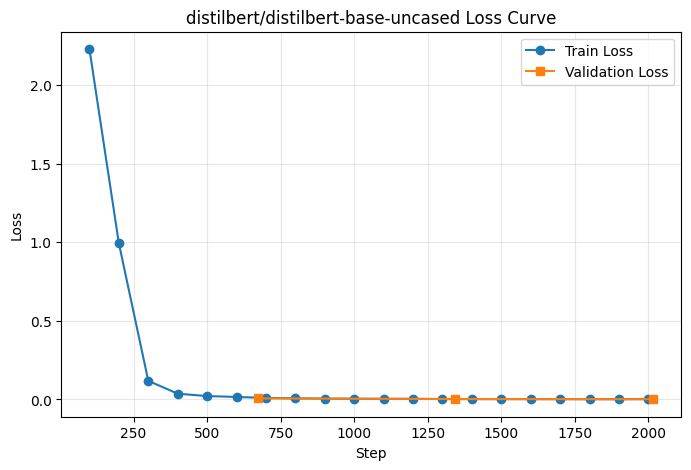

In [7]:
# Uncomment to plot loss curve

plot_loss_curve(enc_trainer.state.log_history, title=f"{encoder_model_id} Loss Curve")

### 4. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Write a **single-example** prediction function (batch size 1 -- this simulates a real routing
request) and feed it to `measure_latency_and_memory` together with `splits["test"]`.

In [8]:
def predict_one_encoder(example):
    """Tokenize a single instruction, run a forward pass, return the argmax label id."""
    inputs = enc_tokenizer(
        example["instruction"], return_tensors="pt", truncation=True, max_length=ENC_MAX_LEN
    ).to(device)
    with torch.no_grad():
        logits = enc_model(**inputs).logits
    return int(torch.argmax(logits, dim=-1).item())

enc_model.eval()
release_training_state(enc_trainer, enc_model)
enc_latency, enc_peak_mem, enc_predictions = measure_latency_and_memory(
    predict_one_encoder, splits["test"]
)
enc_labels = splits["test"]["label"]

enc_metric_dict = get_metrics(enc_labels, enc_predictions)
enc_acc, enc_prec, enc_rec, enc_f1 = (enc_metric_dict["accuracy"], enc_metric_dict["precision"],
                                       enc_metric_dict["recall"], enc_metric_dict["f1_score"])

print(f"Encoder Macro-F1: {enc_f1:.4f}")
print(f"Encoder Latency: {enc_latency:.2f} ms/query")
print(f"Encoder Peak Memory: {enc_peak_mem:.2f} MB")

Encoder Macro-F1: 0.9994
Encoder Latency: 12.08 ms/query
Encoder Peak Memory: 892.47 MB


### 5. Required Plot: Confusion Matrix

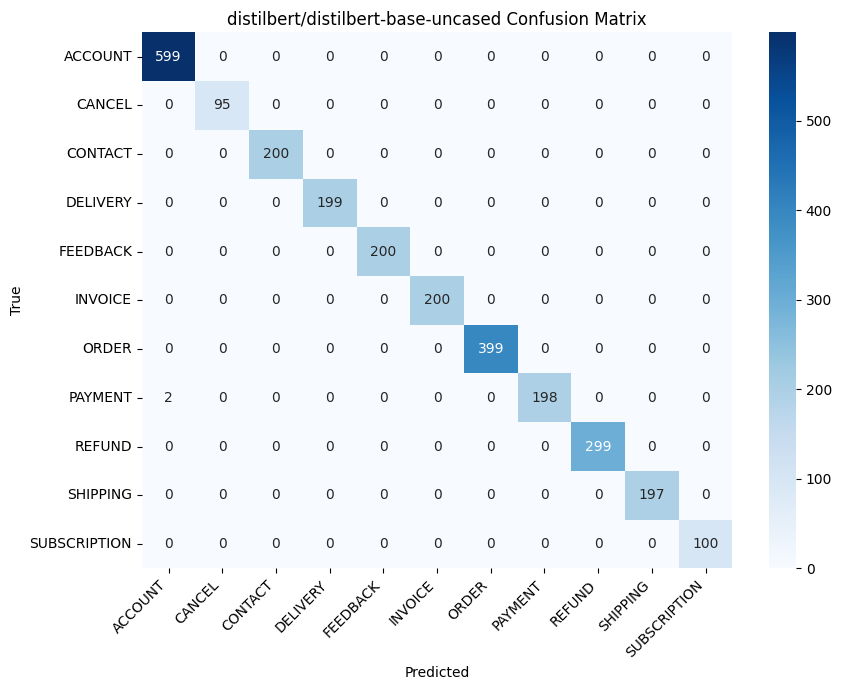

In [9]:
plot_confusion_matrix_heatmap(enc_labels, enc_predictions, TARGET_CATEGORIES,
                               title=f"{encoder_model_id} Confusion Matrix")

# Approach 2: Fine-Tuning Decoder-Only SLM (with / without LoRA)

**Goal:** treat routing as text generation; format each example as an instruction/response pair where the "response" is just the agent name (e.g. `REFUND`), then fine-tune a small decoder-only LM to produce it.

**You need to implement:**
- [ ] Model + tokenizer loading
- [ ] Instruction-formatting function (`format_example`) using a chat template
- [ ] Output parsing (`get_decoder_predictions`) that turns a raw generation into a clean label
- [ ] Tokenization for training
- [ ] LoRA config (or `USE_LORA=False` for full fine-tuning) + `TrainingArguments` + `SFTTrainer`
- [ ] Loss curves, confusion matrix, inference latency, peak GPU memory (same requirements as Approach 1)

**Candidate models:** `Qwen/Qwen2.5-0.5B-Instruct`, `Qwen/Qwen2.5-1.5B-Instruct`

> **GPU memory note:** if you hit memory limits on a free-tier GPU (Colab T4, ~15 GB), use LoRA/QLoRA via `peft` (and consider 4-bit loading via `bitsandbytes`).

### 1. Model & Tokenizer Setup

In [10]:
# TOD: choose your decoder model id
# If a candidate model is gated, authenticate INTERACTIVELY -- never hardcode
# a token in a notebook you submit or share:
#   from huggingface_hub import login; login()

if "enc_model" in globals():
    enc_model.to("cpu")
    del enc_model
if "enc_trainer" in globals():
    del enc_trainer
if "dec_trainer" in globals():
    dec_trainer.model.to("cpu")
    del dec_trainer
if "dec_model" in globals():
    dec_model.to("cpu")
    del dec_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

decoder_model_id = "Qwen/Qwen2.5-0.5B-Instruct" # TODO: Add Decoder Model Id
USE_LORA = True # TODO: Whether to use LORA

dec_tokenizer = AutoTokenizer.from_pretrained(decoder_model_id, trust_remote_code=True)
# Some causal LMs ship without a pad token
# set one if missing.
if dec_tokenizer.pad_token is None:
    dec_tokenizer.pad_token = dec_tokenizer.eos_token

compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
USE_4BIT = False

if USE_LORA and USE_4BIT:
    # QLoRA: load the base model in 4-bit (bitsandbytes) and only train LoRA adapters
    # on top. This is what keeps even the 4B candidate inside a free-tier T4's ~15GB

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, quantization_config=bnb_config, device_map="auto", trust_remote_code=True,
    )
    dec_model = prepare_model_for_kbit_training(dec_model)
else:
    # Full fine-tuning: no quantization.
    # LoRA adapters are attached by SFTTrainer below when USE_LORA=True.
    dec_model = AutoModelForCausalLM.from_pretrained(
        decoder_model_id, torch_dtype=compute_dtype, trust_remote_code=True,
    ).to(device)

dec_model.config.use_cache = False   # required before training with gradient checkpointing

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


### 2. Loading & Formatting the Dataset

Reuse the **same** `splits` `DatasetDict` built in Approach 1's Data Loading step -- do **not**
call `load_dataset` again here. This is what keeps the two approaches' test sets identical.

In [11]:
print(splits)
print(splits["train"][0])

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 21497
    })
    validation: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2687
    })
    test: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response', 'label'],
        num_rows: 2688
    })
})
{'flags': 'BCLW', 'instruction': 'I want to retrieve the damn key of my user, I need help', 'category': 'ACCOUNT', 'intent': 'recover_password', 'response': "No worries at all! I'm here to provide the necessary assistance to retrieve the key of your user account. Let's tackle this together and get you back on track!", 'label': 0}


In [12]:
# TODO: format each example as an instruction: single-token-label pair
LABEL_TEXT_BY_CATEGORY = {category: category.lower() for category in TARGET_CATEGORIES}
LABEL_TOKEN_ID_BY_TEXT = {
    text: dec_tokenizer.encode(text, add_special_tokens=False)
    for text in LABEL_TEXT_BY_CATEGORY.values()
}
assert all(len(ids) == 1 for ids in LABEL_TOKEN_ID_BY_TEXT.values()), LABEL_TOKEN_ID_BY_TEXT
LABEL_TOKEN_ID_BY_TEXT = {text: ids[0] for text, ids in LABEL_TOKEN_ID_BY_TEXT.items()}
VALID_LABEL_TOKEN_IDS = list(LABEL_TOKEN_ID_BY_TEXT.values())
assert len(set(VALID_LABEL_TOKEN_IDS)) == NUM_LABELS

SYS_PROMPT = (
    "You are an AI assistant trained for text classification; given any user "
    f"query, choose the single closest category from this fixed set: {[c.lower() for c in TARGET_CATEGORIES]}; "
    "output only the category name as the final answer without explanation or extra words."
)

def build_prompt(instruction_text):
    """Render the system + user turns with the model's own chat template."""
    messages = [
        {"role": "system", "content": SYS_PROMPT},
        {"role": "user", "content": instruction_text},
    ]
    return dec_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def format_example(example):
    """
    1. Build the chat-templated prompt (system + user turn).
    2. The target is example["category"]
    3. Append the EOS token after the label so the model learns *where to stop*
       generating during training (otherwise it may past the label).
    4. Return {"input_text": prompt + target + eos}.
    """
    ## TODO:
    ## 1. Build the chat-templated prompt (system + user turn).
    ## 2. Extract target from the "example"
    #
    #
    ## YOUR CODE STARTS HERE
    prompt = build_prompt(example["instruction"])
    target = LABEL_TEXT_BY_CATEGORY[example["category"]]
    ## YOUR CODE ENDS HERE

    return {"input_text": prompt + target + dec_tokenizer.eos_token}

# Apply it across every split, keeping the original instruction text around
formatted_splits = splits.map(
    lambda ex: {**format_example(ex), "original_text": ex["instruction"]}
)

Map: 100%|██████████| 2688/2688 [00:00<00:00, 3746.44 examples/s]


### 3. Baseline Check: Zero-Shot Inference (Before Fine-Tuning)

In [13]:
# Given: greedy-decodes up to max_new_tokens tokens (a label is one word, so 5 is generous headroom).
def get_outputs(model, inputs, max_new_tokens=1):
    return model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        eos_token_id=dec_tokenizer.eos_token_id,
        pad_token_id=dec_tokenizer.pad_token_id,
        do_sample=False,
        prefix_allowed_tokens_fn=lambda batch_id, input_ids: VALID_LABEL_TOKEN_IDS,
    )

def normalize_decoder_output(text, valid_categories=None):
    """Lowercase + strip everything but letters, then snap to a known category if the
    raw text contains one as a substring (handles the model echoing extra words/punctuation
    around the label). Falls back to the cleaned string, which will simply score as an
    incorrect prediction rather than crash the metric computation."""
    valid_categories = valid_categories or [c.lower() for c in TARGET_CATEGORIES]
    cleaned = re.sub(r"[^a-z]", "", text.lower())
    for cat in valid_categories:
        if cat in cleaned:
            return cat
    return cleaned

# TODO: turn a raw generation into a clean predicted category string
def get_decoder_predictions(dataset, model):
    """For every row: rebuild the chat prompt from row["original_text"], generate,
    decode only the newly-generated tokens, and normalise. Returns (labels, predictions),
    both lists of lowercased strings."""
    labels, predictions = [], []
    model.eval()
    for row in dataset:
        prompt = build_prompt(row["original_text"])
        inputs = dec_tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            output_ids = get_outputs(model, inputs)
        new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
        decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
        predictions.append(normalize_decoder_output(decoded))
        labels.append(row["category"].lower())
    return labels, predictions

zero_shot_subset = formatted_splits["validation"].select(range(min(500, len(formatted_splits["validation"]))))
dec_labels, dec_preds = get_decoder_predictions(zero_shot_subset, dec_model)
print("Zero-shot (pre-fine-tuning) baseline:", get_metrics(dec_labels, dec_preds))

Zero-shot (pre-fine-tuning) baseline: {'accuracy': 0.586, 'precision': 0.5880862001462093, 'recall': 0.5865045944011471, 'f1_score': 0.5254590482107679}


### 4. Tokenization for Training

In [14]:
# TODO: tokenize the formatted training data
_dec_lengths = [len(dec_tokenizer.encode(t)) for t in formatted_splits["train"]["input_text"][:1000]]
print(f"Formatted prompt+label token length -- mean: {np.mean(_dec_lengths):.1f}, "
      f"95th pct: {np.percentile(_dec_lengths, 95):.0f}, max: {max(_dec_lengths)}")

DEC_MAX_LEN = 256  # TODO: ADD Decoder Mex len: cover SYS_PROMPT + longest instruction + label + EOS

def tokenize_function(example):
    """Tokenize input_text and mask prompt tokens so loss is computed on label + EOS only."""
    prompt = build_prompt(example["original_text"])
    prompt_ids = dec_tokenizer(prompt, add_special_tokens=False)["input_ids"]
    completion_ids = [
        LABEL_TOKEN_ID_BY_TEXT[example["category"].lower()],
        dec_tokenizer.eos_token_id,
    ]
    prompt_ids = prompt_ids[:DEC_MAX_LEN - len(completion_ids)]
    input_ids = prompt_ids + completion_ids
    return {
        "input_ids": input_ids,
        "attention_mask": [1] * len(input_ids),
        "labels": [-100] * len(prompt_ids) + completion_ids,
    }

dec_tokenized = formatted_splits.map(
    tokenize_function,
    remove_columns=formatted_splits["train"].column_names,
)

def completion_only_collator(features):
    max_len = max(len(feature["input_ids"]) for feature in features)
    batch = {"input_ids": [], "attention_mask": [], "labels": []}
    for feature in features:
        pad_len = max_len - len(feature["input_ids"])
        batch["input_ids"].append(feature["input_ids"] + [dec_tokenizer.pad_token_id] * pad_len)
        batch["attention_mask"].append(feature["attention_mask"] + [0] * pad_len)
        batch["labels"].append(feature["labels"] + [-100] * pad_len)
    return {key: torch.tensor(value, dtype=torch.long) for key, value in batch.items()}

Formatted prompt+label token length -- mean: 98.1, 95th pct: 103, max: 108


Map: 100%|██████████| 2688/2688 [00:02<00:00, 1160.46 examples/s]


### 5. LoRA Config & Training Arguments

In [15]:
peft_config = None
if USE_LORA:
    peft_config = LoraConfig(
        r=16,               # TODO: tune rank of the low-rank update matrices
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
        target_modules="all-linear",
    )

dec_train_args = SFTConfig(
    output_dir=f"{decoder_model_id.split('/')[-1]}-router-finetuned/",
    per_device_train_batch_size=4, # Tune batch size
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=16,
    optim="adamw_torch",
    learning_rate=2e-4, # TODO: Tune learning rate
    max_grad_norm=1.0,
    num_train_epochs=1,        # TODO: Tune epoch
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    logging_strategy="steps",
    logging_steps=20,
    eval_strategy="steps",     # NOTE: required so eval_loss appears in log_history for the loss-curve plot
    eval_steps=100,
    save_strategy="no",
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    seed=RANDOM_SEED,
    data_seed=RANDOM_SEED,
    report_to="none",
    max_length=DEC_MAX_LEN,
    packing=False,
    label_names=["labels"],
    remove_unused_columns=False,
    dataset_kwargs={"skip_prepare_dataset": True},
)

### 6. Model Training

In [16]:
## Supervised Fine-Tuning (SFT)
dec_trainer = SFTTrainer(
    model=dec_model,
    train_dataset=dec_tokenized["train"],
    eval_dataset=dec_tokenized["validation"],
    peft_config=peft_config,
    args=dec_train_args,
    processing_class=dec_tokenizer,
    data_collator=completion_only_collator,
)

if USE_LORA:
    dec_trainer.model.print_trainable_parameters()
print("Training Decoder Model...")
dec_trainer.train()

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497
Training Decoder Model...


Step,Training Loss,Validation Loss
100,0.011200,0.010004
200,0.003500,0.002525
300,0.004000,0.000395


TrainOutput(global_step=335, training_loss=0.026311690430504395, metrics={'train_runtime': 5840.965, 'train_samples_per_second': 3.68, 'train_steps_per_second': 0.057, 'total_flos': 4780062545433600.0, 'train_loss': 0.026311690430504395})

### 7. Required Plot: Training & Validation Loss Curves

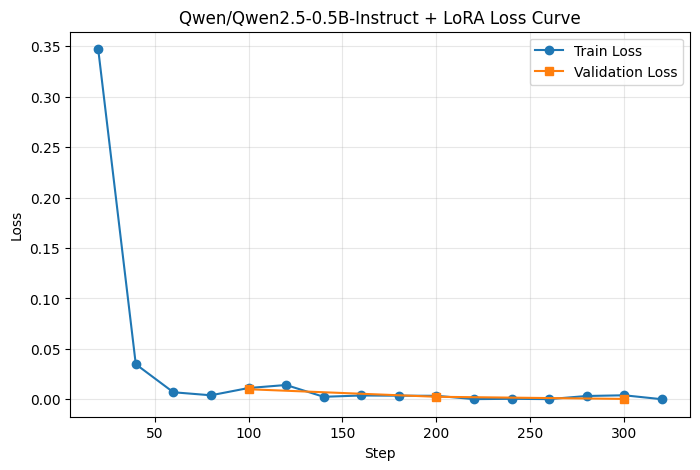

In [17]:
plot_loss_curve(dec_trainer.state.log_history,
                title=f"{decoder_model_id}{' + LoRA' if USE_LORA else ''} Loss Curve")

### 8. Evaluation: Metrics, Confusion Matrix, Latency, Peak GPU Memory

Reuse `get_decoder_predictions`, but now pass `dec_trainer.model` (the fine-tuned weights). For latency/memory, write a single-example version and pass it to `measure_latency_and_memory`, just like you did for the encoder.

In [18]:
# Evaluate the FINE-TUNED decoder on the held-out test set
def predict_one_decoder(example):
    """Single-example version of get_decoder_predictions's inner loop"""
    prompt = build_prompt(example["original_text"])
    inputs = dec_tokenizer(prompt, return_tensors="pt").to(dec_trainer.model.device)
    output_ids = get_outputs(dec_trainer.model, inputs)
    new_tokens = output_ids[0][inputs["input_ids"].shape[1]:]
    decoded = dec_tokenizer.decode(new_tokens, skip_special_tokens=True)
    return normalize_decoder_output(decoded)

dec_trainer.model.gradient_checkpointing_disable()
dec_trainer.model.config.use_cache = True
dec_trainer.model.eval()
release_training_state(dec_trainer, dec_trainer.model)
dec_latency, dec_peak_mem, dec_predictions = measure_latency_and_memory(
    predict_one_decoder, list(formatted_splits["test"])
)
dec_labels = [ex["category"].lower() for ex in formatted_splits["test"]]

dec_metric_dict = get_metrics(dec_labels, dec_predictions)
dec_acc, dec_prec, dec_rec, dec_f1 = (dec_metric_dict["accuracy"], dec_metric_dict["precision"],
                                       dec_metric_dict["recall"], dec_metric_dict["f1_score"])
print(dec_metric_dict)
print(f"Decoder Latency: {dec_latency:.2f} ms/query")
print(f"Decoder Peak Memory: {dec_peak_mem:.2f} MB")

{'accuracy': 0.9992559523809523, 'precision': 0.999317612212349, 'recall': 0.999317612212349, 'f1_score': 0.999317612212349}
Decoder Latency: 120.36 ms/query
Decoder Peak Memory: 1076.61 MB


### 9. Required Plot: Confusion Matrix

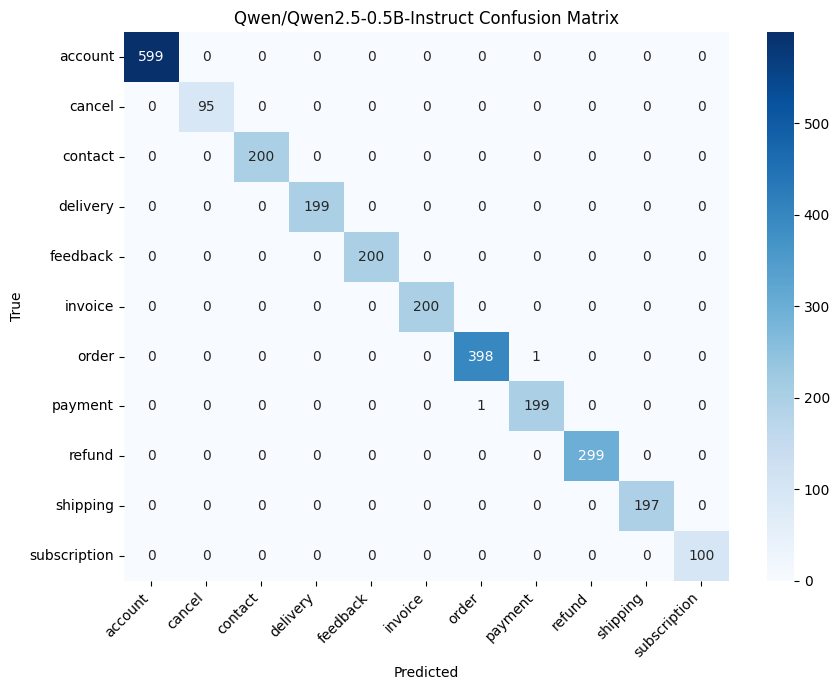

In [19]:
plot_confusion_matrix_heatmap(dec_labels, dec_predictions,
                               [c.lower() for c in TARGET_CATEGORIES],
                               title=f"{decoder_model_id} Confusion Matrix")

## 7. Comparison

Both cells below are given (pure plotting/table), they assume the variable names
used throughout this notebook (`enc_*` / `dec_*`). If you renamed anything,update the references accordingly.

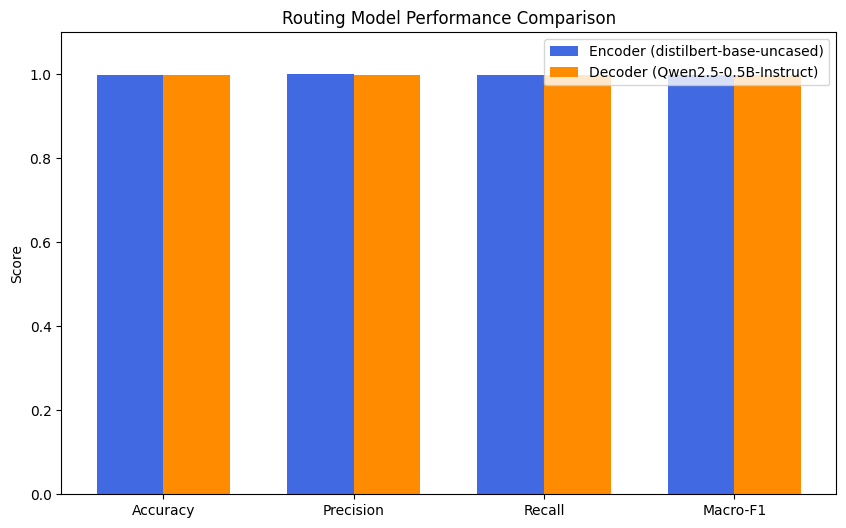

In [20]:
# Comparison bar chart
metrics_names = ["Accuracy", "Precision", "Recall", "Macro-F1"]
enc_scores = [enc_acc, enc_prec, enc_rec, enc_f1]
dec_scores = [dec_acc, dec_prec, dec_rec, dec_f1]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, enc_scores, width, label=f"Encoder ({encoder_model_id.split('/')[-1]})", color="royalblue")
ax.bar(x + width/2, dec_scores, width, label=f"Decoder ({decoder_model_id.split('/')[-1]})", color="darkorange")
ax.set_ylabel("Score")
ax.set_title("Routing Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
plt.ylim(0, 1.1)
plt.show()

In [21]:
# Dedicated comparison table with measured values
# fill in by running the cells above
comparison_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "Macro-F1", "Accuracy",
               "Peak GPU Memory (MB)", "Inference Latency (ms/query)"],
    f"Encoder ({encoder_model_id})": [enc_prec, enc_rec, enc_f1, enc_acc, enc_peak_mem, enc_latency],
    f"Decoder SLM ({decoder_model_id}{' + LoRA' if USE_LORA else ''})":
        [dec_prec, dec_rec, dec_f1, dec_acc, dec_peak_mem, dec_latency],
})
comparison_table

,Metric,Encoder (distilbert/distilbert-base-uncased),Decoder SLM (Qwen/Qwen2.5-0.5B-Instruct + LoRA)
0,Precision,0.999697,0.999318
1,Recall,0.999091,0.999318
2,Macro-F1,0.999392,0.999318
3,Accuracy,0.999256,0.999256
4,Peak GPU Memory (MB),892.471680,1076.607910
5,Inference Latency (ms/query),12.078934,120.359293


## 8. Recommendation
**To: Engineering Lead, ShopAssist AI**  
```
I recommend deploying the fine-tuned DistilBERT encoder as ShopAssist AI's production router. On the held-out test set, it achieved a macro-F1 of 0.999392 and accuracy of 0.999256, matching the decoder's accuracy while slightly exceeding its 0.999318 macro-F1. The operational advantage is much larger: DistilBERT averaged 12.08 ms per query versus 120.36 ms for Qwen2.5-0.5B + LoRA, making it about 10 times faster, and its measured peak inference GPU memory was 892.47 MB versus 1,076.61 MB. Those results make the encoder the more cost-efficient choice for a high-volume routing service without sacrificing test-set quality. The main production risk is distribution shift: real tickets may contain new products, mixed intents, slang, multilingual text, or non-routing chit-chat that is unlike this benchmark, causing confidently wrong handoffs. I would log predicted class probabilities, latency, and downstream reroute or human-handoff outcomes; monitor class-level precision, recall, macro-F1, confidence calibration, and input drift on a regularly labeled sample; establish alerts for metric or confidence changes; and send low-confidence or out-of-domain messages to a safe fallback queue. We should retrain only after validating drift data on a time-separated holdout.
```
---


## 7. Reflection

### Q1: On what transfers from pretraining
```
Pretraining supplied both models with general representations of vocabulary, syntax, paraphrases, tone, and semantic relationships, so phrases such as "charged twice" and "money back" could already be recognized as related concepts. The decoder also brought next-token generation and instruction-following behavior. Fine-tuning had to learn the task-specific decision boundary: which patterns map to each of ShopAssist AI's eleven categories. It also had to train the encoder's randomly initialized classification head and teach the decoder's LoRA adapters and added label-token embeddings to produce exactly the required agent token. Thus, pretraining provided language understanding, while fine-tuning learned this dataset's label ontology and output protocol. The decoder's pre-fine-tuning macro-F1 of 0.525459 shows that pretraining transferred useful knowledge but did not by itself learn the required routing map.
```
### Q2: On Handling Chit-Chat Queries
If a user sends *"Hey! How’s it going?"*:
```
As implemented, both approaches must choose one of the eleven known agents, so neither can correctly abstain on "Hey! How's it going?" The encoder assigns the message to whichever softmax class has the highest score, even though every class is inappropriate. The decoder is constrained to generate one allowed label token, so its fluent conversational pretraining cannot produce a chit-chat response; it also returns the closest supported class. The encoder fails somewhat more gracefully operationally because its full class-probability distribution is cheap to expose, calibrate, and threshold, although that safeguard is not part of the current benchmark. In production, I would add an OUT_OF_SCOPE/CHIT_CHAT class with varied negative examples, calibrate confidence on a separate validation set, and combine a confidence or energy threshold with an out-of-distribution detector. Messages rejected by that gate should go to a lightweight conversational agent or human fallback rather than a specialist. I would monitor abstention rate, false accepts, downstream reroutes, and newly observed out-of-scope clusters.
```